In [15]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from tqdm import tqdm
import numpy as np

# 1. โหลดข้อมูล
df = pd.read_csv('data/cleaned_features_ready_to_train.csv')
X = df.drop(columns=['Target_Dangerous'])
if 'AnimalName' in X.columns: X = X.drop(columns=['AnimalName'])
y = df['Target_Dangerous']

# 2. แบ่งข้อมูลแบบมาตรฐาน (70:15:15)
# ขั้นแรก: แยก Test Set (สอบปลายภาค) ออกมา 15%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# ขั้นที่สอง: แบ่งจากส่วนที่เหลือเป็น Train (เรียนรู้) 70% และ Validation (สอบย่อย) 15%
# (สัดส่วน 0.176 ของ 85% จะเท่ากับประมาณ 15% ของทั้งหมด)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Data Loaded:")
print(f" - Training set: {X_train.shape[0]} samples (70%)")
print(f" - Validation set: {X_val.shape[0]} samples (15%)")
print(f" - Test set: {X_test.shape[0]} samples (15%)")


Data Loaded:
 - Training set: 894 samples (70%)
 - Validation set: 192 samples (15%)
 - Test set: 192 samples (15%)


In [ ]:
# ตั้งค่า Folder
model_path = 'models/randomforest'
if not os.path.exists(model_path): os.makedirs(model_path)

# เทรนแบบ Warm Start เพื่อดึงค่า Accuracy ระหว่างทาง
n_trees = 100
# ปรับใหม่ให้ยืดหยุ่นขึ้น (Pruning)
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=8,         # จำกัดความลึก ไม่ให้จำรายละเอียดขยะ
    min_samples_leaf=10,   # ต้องมีข้อมูลอย่างน้อย 5 ตัวอย่างถึงจะยอมสร้างกิ่งใหม่
    max_features=0.2,
    random_state=42, 
    class_weight='balanced'
)

train_scores = []
test_scores = []

print("🚀 Training Random Forest...")
for i in tqdm(range(1, n_trees + 1)):
    model.n_estimators = i
    model.fit(X_train, y_train)
    
    # เก็บค่าไปพลอต Graph 1
    train_scores.append(model.score(X_train, y_train))
    # เปลี่ยนจาก X_test เป็น X_val เพื่อดูว่าโมเดล Overfitting ไหมระหว่างเทรน
    test_scores.append(model.score(X_val, y_val))

# บันทึกโมเดล
joblib.dump(model, f'{model_path}/animal_risk_model.pkl')
joblib.dump(X.columns.tolist(), f'{model_path}/feature_columns.pkl')
print(f"✅ Model saved to {model_path}")

🚀 Training Random Forest...


100%|██████████| 100/100 [00:16<00:00,  5.94it/s]

✅ Model saved to models/randomforest


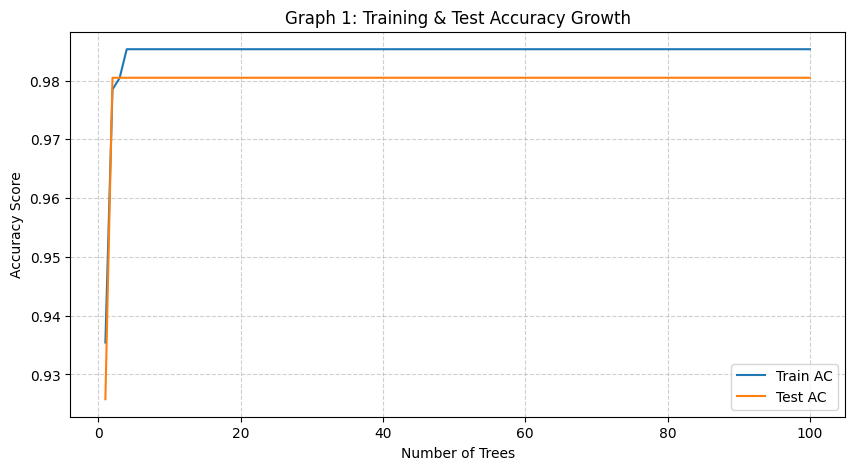

C:\Users\user\AppData\Local\Temp\ipykernel_31800\903330653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


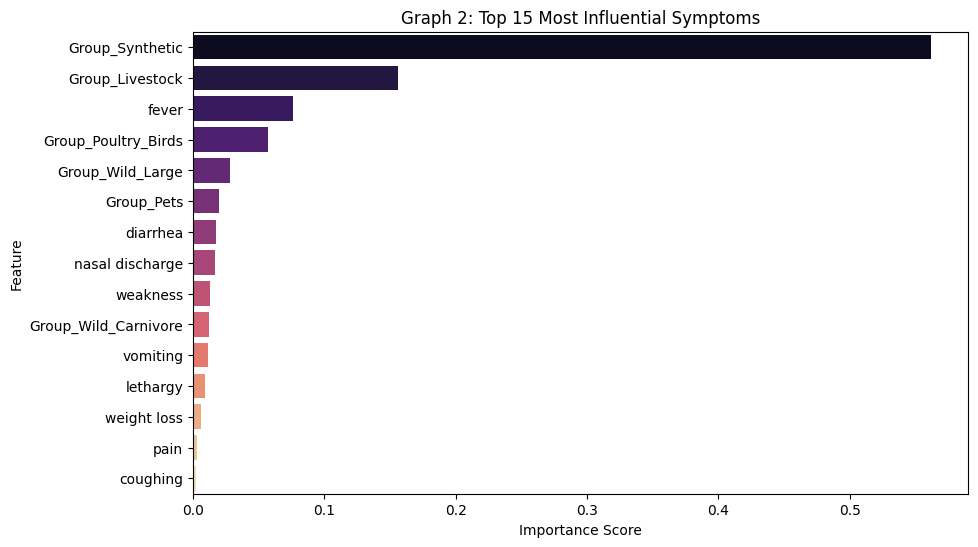

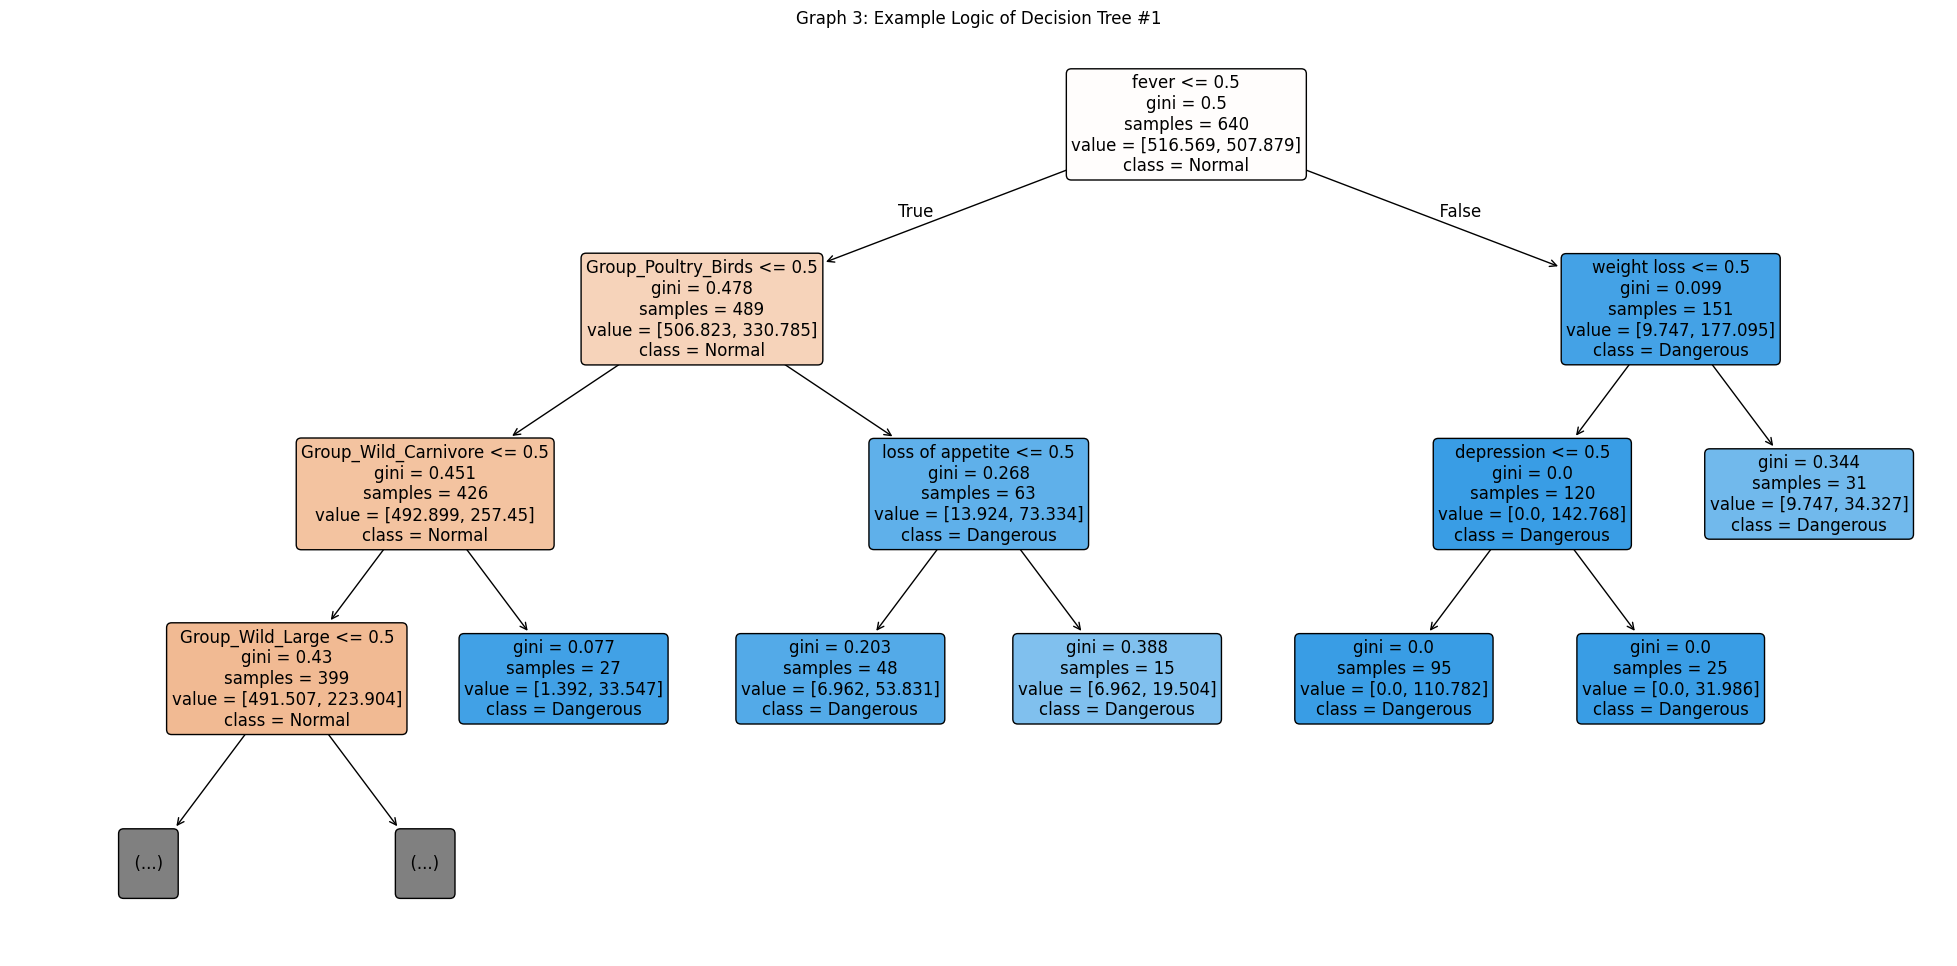

In [ ]:
# --- Graph 1: Training Graph (Learning Curve) ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_trees + 1), train_scores, label='Train AC', color='#1f77b4')
plt.plot(range(1, n_trees + 1), test_scores, label='Val AC', color='#ff7f0e') # เปลี่ยนตรงนี้
plt.title('Graph 1: Training & Validation Accuracy Growth') # เปลี่ยนตรงนี้
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Graph 2: Feature Importance (Explainable AI) ---
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')
plt.title('Graph 2: Top 15 Most Influential Symptoms')
plt.xlabel('Importance Score')
plt.show()

# --- Graph 3: Decision Tree Visual (Logic Structure) ---
plt.figure(figsize=(25, 12))
tree.plot_tree(model.estimators_[0], 
               feature_names=X.columns,  
               class_names=['Normal', 'Dangerous'],
               filled=True, 
               max_depth=3, # ดูแค่ 3 ชั้นแรกเพื่อความชัดเจน
               fontsize=12,
               rounded=True)
plt.title('Graph 3: Example Logic of Decision Tree #1')
plt.show()

🔍 กำลังวิเคราะห์อาการเสี่ยงของสัตว์จริง 6 กลุ่ม...


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


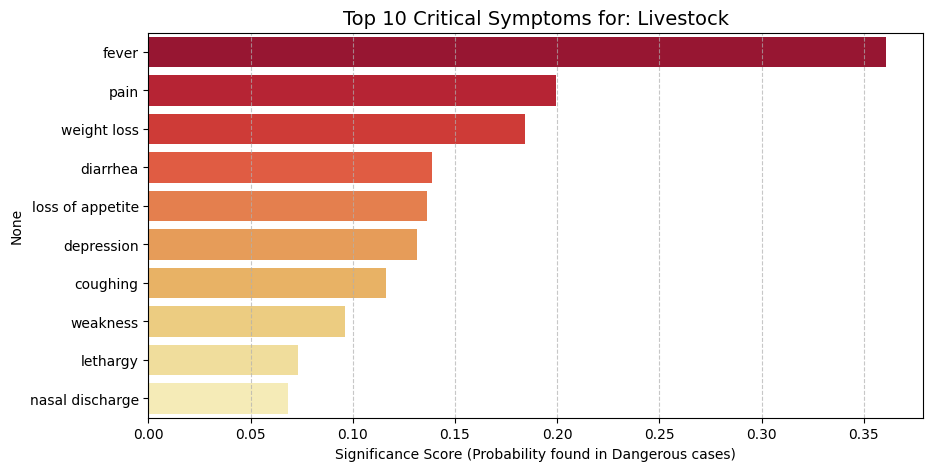

📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Livestock:
   1. fever (36.1%)
   2. pain (19.9%)
   3. weight loss (18.4%)
   4. diarrhea (13.9%)
   5. loss of appetite (13.6%)
   6. depression (13.1%)
   7. coughing (11.6%)
   8. weakness (9.6%)
   9. lethargy (7.3%)
   10. nasal discharge (6.8%)
------------------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


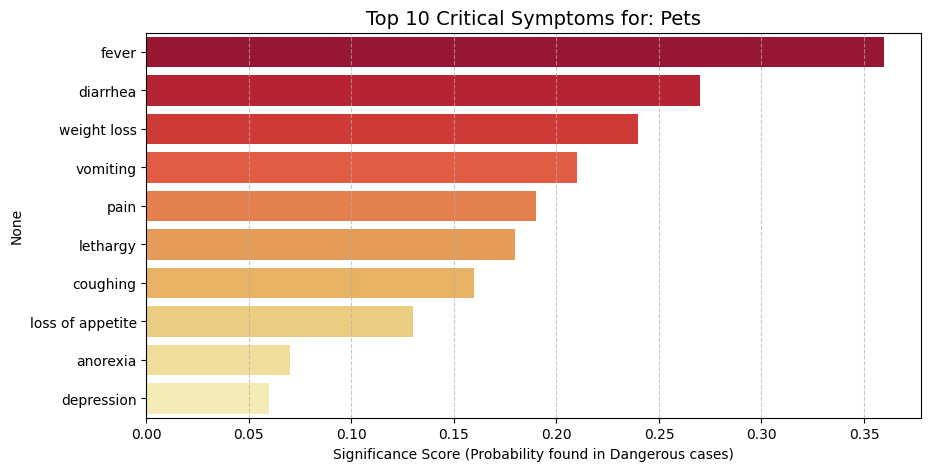

C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Pets:
   1. fever (36.0%)
   2. diarrhea (27.0%)
   3. weight loss (24.0%)
   4. vomiting (21.0%)
   5. pain (19.0%)
   6. lethargy (18.0%)
   7. coughing (16.0%)
   8. loss of appetite (13.0%)
   9. anorexia (7.0%)
   10. depression (6.0%)
------------------------------------------------------------


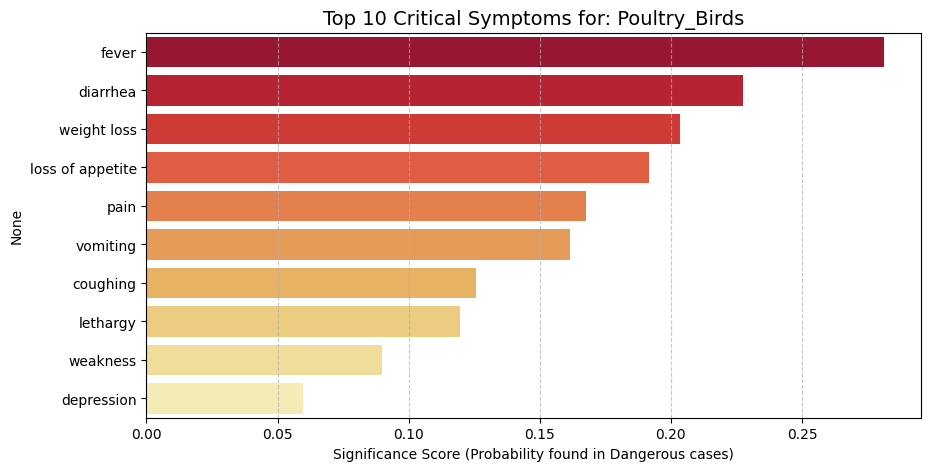

📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Poultry_Birds:
   1. fever (28.1%)
   2. diarrhea (22.8%)
   3. weight loss (20.4%)
   4. loss of appetite (19.2%)
   5. pain (16.8%)
   6. vomiting (16.2%)
   7. coughing (12.6%)
   8. lethargy (12.0%)
   9. weakness (9.0%)
   10. depression (6.0%)
------------------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


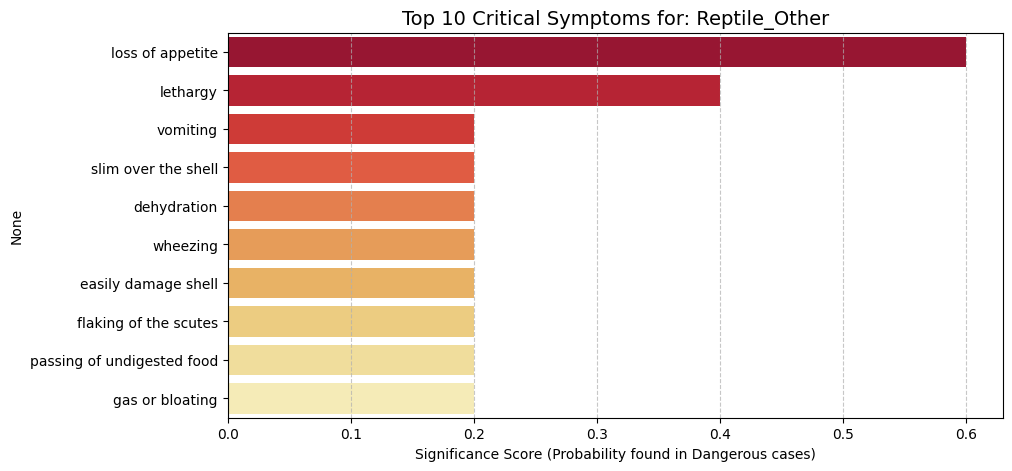

📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Reptile_Other:
   1. loss of appetite (60.0%)
   2. lethargy (40.0%)
   3. vomiting (20.0%)
   4. slim over the shell (20.0%)
   5. dehydration (20.0%)
   6. wheezing (20.0%)
   7. easily damage shell (20.0%)
   8. flaking of the scutes (20.0%)
   9. passing of undigested food (20.0%)
   10. gas or bloating (20.0%)
------------------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


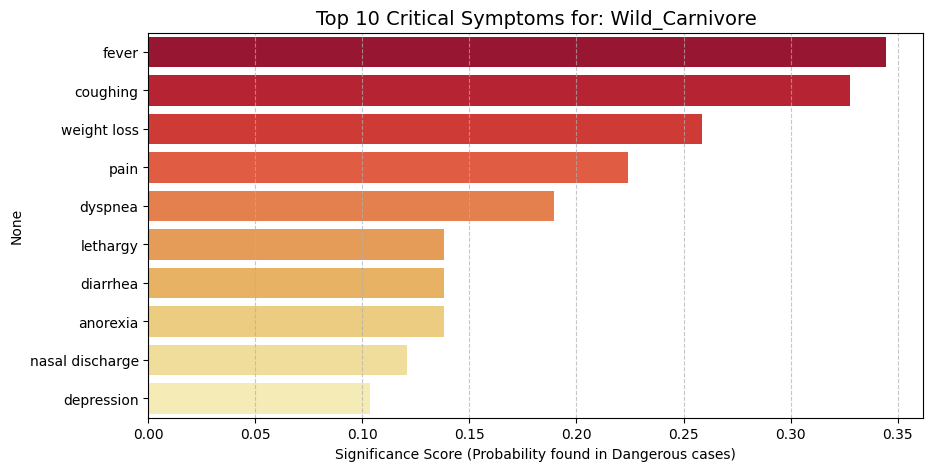

📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Wild_Carnivore:
   1. fever (34.5%)
   2. coughing (32.8%)
   3. weight loss (25.9%)
   4. pain (22.4%)
   5. dyspnea (19.0%)
   6. lethargy (13.8%)
   7. diarrhea (13.8%)
   8. anorexia (13.8%)
   9. nasal discharge (12.1%)
   10. depression (10.3%)
------------------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1576007524.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')


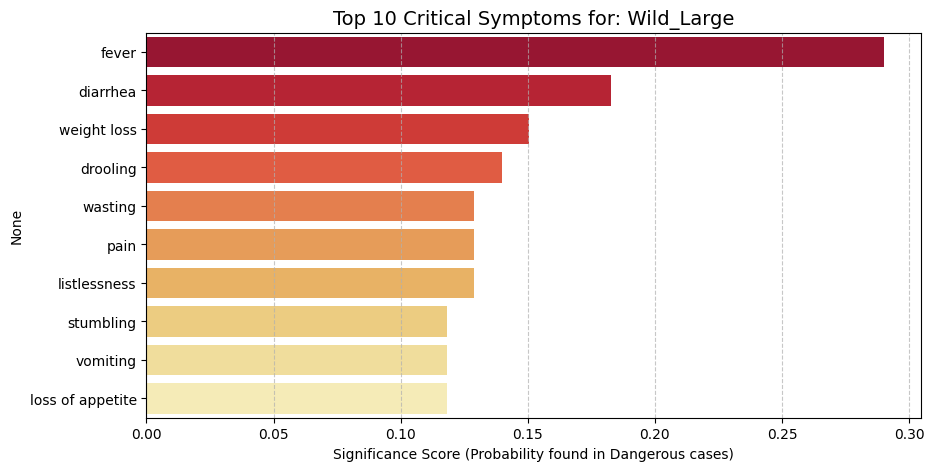

📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม Wild_Large:
   1. fever (29.0%)
   2. diarrhea (18.3%)
   3. weight loss (15.1%)
   4. drooling (14.0%)
   5. wasting (12.9%)
   6. pain (12.9%)
   7. listlessness (12.9%)
   8. stumbling (11.8%)
   9. vomiting (11.8%)
   10. loss of appetite (11.8%)
------------------------------------------------------------


In [6]:
# --- ส่วนที่ปรับปรุง: วิเคราะห์อาการเสี่ยงรายกลุ่มสัตว์ (ซ่อนกลุ่ม Synthetic) ---

# 1. ระบุรายชื่อกลุ่มสัตว์ (ไม่เอา Group_Synthetic)
all_groups = [col for col in X.columns if col.startswith('Group_')]
real_animal_groups = [g for g in all_groups if g != 'Group_Synthetic']

print(f"🔍 กำลังวิเคราะห์อาการเสี่ยงของสัตว์จริง {len(real_animal_groups)} กลุ่ม...")

for group in real_animal_groups:
    group_name = group.replace('Group_', '')
    
    # 2. กรองเฉพาะสัตว์ในกลุ่มนี้ที่เป็น "Dangerous" (Target=1)
    mask = (df[group] == 1) & (df['Target_Dangerous'] == 1)
    df_group_risk = df[mask]
    
    if len(df_group_risk) > 0:
        # 3. คำนวณอาการเสี่ยง (ข้ามคอลัมน์กลุ่มสัตว์ทั้งหมดและ Target)
        symptom_cols = [col for col in X.columns if not col.startswith('Group_')]
        risk_logic = df_group_risk[symptom_cols].mean().sort_values(ascending=False).head(10)
        
        # 4. แสดงผลกราฟ
        plt.figure(figsize=(10, 5))
        sns.barplot(x=risk_logic.values, y=risk_logic.index, palette='YlOrRd_r')
        plt.title(f'Top 10 Critical Symptoms for: {group_name}', fontsize=14)
        plt.xlabel('Significance Score (Probability found in Dangerous cases)')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.show()
        
        print(f"📌 อาการที่ต้องเฝ้าระวังสำหรับกลุ่ม {group_name}:")
        for i, (sym, val) in enumerate(risk_logic.items(), 1):
            print(f"   {i}. {sym} ({val*100:.1f}%)")
        print("-" * 60)
    else:
        print(f"⚠️ กลุ่ม {group_name}: ไม่มีข้อมูลเคสอันตรายเพื่อนำมาวิเคราะห์")

In [7]:
# เช็คจำนวนข้อมูลกลุ่ม Synthetic แยกตามความเสี่ยง
print("🔍 ตรวจสอบกลุ่ม Synthetic:")
synthetic_check = df[df['Group_Synthetic'] == 1]['Target_Dangerous'].value_counts()
print(synthetic_check)

if len(synthetic_check) == 0:
    print("❌ ไม่มีสัตว์ในกลุ่ม Synthetic เลยในไฟล์ CSV นี้")
elif 1 not in synthetic_check.index:
    print("⚠️ มีสัตว์กลุ่ม Synthetic แต่ 'ไม่มีตัวไหนที่อันตราย (1)' เลย กราฟจึงไม่โชว์")

🔍 ตรวจสอบกลุ่ม Synthetic:
Target_Dangerous
0    439
Name: count, dtype: int64
⚠️ มีสัตว์กลุ่ม Synthetic แต่ 'ไม่มีตัวไหนที่อันตราย (1)' เลย กราฟจึงไม่โชว์


📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        92
           1       0.97      1.00      0.98       164

    accuracy                           0.98       256
   macro avg       0.99      0.97      0.98       256
weighted avg       0.98      0.98      0.98       256



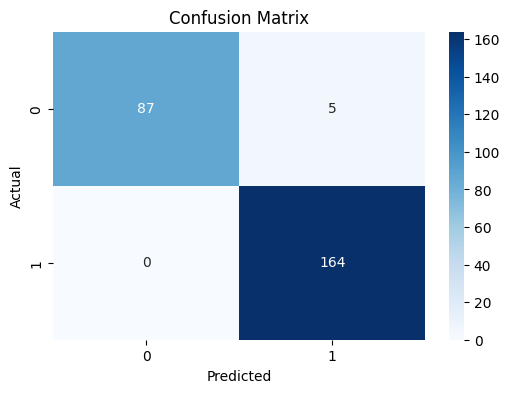

In [8]:
y_pred = model.predict(X_test)
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
from sklearn.tree import export_text

# ดึงต้นไม้ต้นแรก (index 0) ออกมาดูกฎ
tree_rules = export_text(model.estimators_[0], feature_names=X.columns.tolist())
print(tree_rules)

|--- fever <= 0.50
|   |--- Group_Poultry_Birds <= 0.50
|   |   |--- Group_Wild_Carnivore <= 0.50
|   |   |   |--- Group_Wild_Large <= 0.50
|   |   |   |   |--- weight loss <= 0.50
|   |   |   |   |   |--- Group_Synthetic <= 0.50
|   |   |   |   |   |   |--- Group_Pets <= 0.50
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- Group_Pets >  0.50
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- Group_Synthetic >  0.50
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- weight loss >  0.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- Group_Wild_Large >  0.50
|   |   |   |   |--- class: 1.0
|   |   |--- Group_Wild_Carnivore >  0.50
|   |   |   |--- class: 1.0
|   |--- Group_Poultry_Birds >  0.50
|   |   |--- loss of appetite <= 0.50
|   |   |   |--- class: 1.0
|   |   |--- loss of appetite >  0.50
|   |   |   |--- class: 1.0
|--- fever >  0.50
|   |--- weight loss <= 0.50
|   |   |--- depression <= 0.50
|   |   |   |--- class: 1.0

In [10]:
import joblib
import pandas as pd
import numpy as np

# 1. โหลดโมเดลและรายชื่อ Feature ที่เคยบันทึกไว้
model = joblib.load('models/randomforest/animal_risk_model.pkl')
feature_columns = joblib.load('models/randomforest/feature_columns.pkl')

def create_test_case(group_name, symptoms_list):
    # สร้าง DataFrame เปล่าที่มีคอลัมน์ครบตามที่โมเดลต้องการ (ค่าเริ่มต้นเป็น 0 ทั้งหมด)
    test_df = pd.DataFrame(0, index=[0], columns=feature_columns)
    
    # ตั้งค่ากลุ่มสัตว์ (เช่น Group_Pets = 1 หรือ Group_Reptile_Other = 1)
    group_col = f'Group_{group_name}'
    if group_col in feature_columns:
        test_df[group_col] = 1
    
    # ตั้งค่าอาการ (เช่น sym_fever = 1)
    for sym in symptoms_list:
        if sym in feature_columns:
            test_df[sym] = 1
            
    return test_df

# 2. สร้างเคสทดสอบ: หมาเป็นไข้ VS เต่าเป็นไข้
# สมมติว่าอาการไข้ในไฟล์ของคุณใช้ชื่อคอลัมน์ว่า 'sym_fever' (ปรับชื่อตามจริงของคุณได้เลย)
symptoms = ['sym_fever'] 

case_dog = create_test_case('Pets', symptoms)
case_turtle = create_test_case('Reptile_Other', symptoms)

# 3. ทำนายผล
prob_dog = model.predict_proba(case_dog)[0]
prob_turtle = model.predict_proba(case_turtle)[0]

print("🧪 --- ผลการทดสอบความอันตราย (Risk Prediction) ---")
print(f"🐶 [สุนัข] อาการ: {symptoms}")
print(f"   - โอกาสปกติ: {prob_dog[0]*100:.2f}%")
print(f"   - โอกาสอันตราย: {prob_dog[1]*100:.2f}%")

print(f"\n🐢 [เต่า] อาการ: {symptoms}")
print(f"   - โอกาสปกติ: {prob_turtle[0]*100:.2f}%")
print(f"   - โอกาสอันตราย: {prob_turtle[1]*100:.2f}%")

# 4. วิเคราะห์เหตุผลเบื้องหลัง (สรุป Logic)
if prob_dog[1] != prob_turtle[1]:
    print("\n💡 วิเคราะห์:")
    print("โมเดลให้ค่าน้ำหนักความอันตรายไม่เท่ากัน เพราะเรียนรู้จาก Data ว่า")
    print("กลุ่มสัตว์ที่ต่างกัน เมื่อมีอาการเดียวกัน มีโอกาสเกิดภาวะแทรกซ้อนหรืออัตราการตายที่ต่างกัน")

🧪 --- ผลการทดสอบความอันตราย (Risk Prediction) ---
🐶 [สุนัข] อาการ: ['sym_fever']
   - โอกาสปกติ: 8.49%
   - โอกาสอันตราย: 91.51%

🐢 [เต่า] อาการ: ['sym_fever']
   - โอกาสปกติ: 16.72%
   - โอกาสอันตราย: 83.28%

💡 วิเคราะห์:
โมเดลให้ค่าน้ำหนักความอันตรายไม่เท่ากัน เพราะเรียนรู้จาก Data ว่า
กลุ่มสัตว์ที่ต่างกัน เมื่อมีอาการเดียวกัน มีโอกาสเกิดภาวะแทรกซ้อนหรืออัตราการตายที่ต่างกัน


In [11]:
# ทดสอบคู่ที่ต่างกันสุดขั้ว
symptoms_test = ['loss of appetite'] # เปลี่ยนชื่อตามคอลัมน์จริงในไฟล์คุณ

case_bird = create_test_case('Poultry_Birds', symptoms_test)
case_wild = create_test_case('Wild_Carnivore', symptoms_test)

prob_bird = model.predict_proba(case_bird)[0]
prob_wild = model.predict_proba(case_wild)[0]

print(f"🐔 [กลุ่มสัตว์ปีก] อาการซึม: อันตราย {prob_bird[1]*100:.2f}%")
print(f"🐺 [กลุ่มสัตว์ป่ากินเนื้อ] อาการซึม: อันตราย {prob_wild[1]*100:.2f}%")

🐔 [กลุ่มสัตว์ปีก] อาการซึม: อันตราย 88.53%
🐺 [กลุ่มสัตว์ป่ากินเนื้อ] อาการซึม: อันตราย 89.87%


In [12]:
results = []
# วนลูปเช็คทุกกลุ่มสัตว์ และ ทุกอาการ
symptom_cols = [col for col in X.columns if not col.startswith('Group_')]
animal_groups = [col for col in X.columns if col.startswith('Group_') and col != 'Group_Synthetic']

for sym in symptom_cols:
    probs = {}
    for group in animal_groups:
        test_case = create_test_case(group.replace('Group_', ''), [sym])
        prob = model.predict_proba(test_case)[0][1]
        probs[group] = prob
    
    # หาค่าความต่างสูงสุด-ต่ำสุดในแต่ละอาการ
    diff = max(probs.values()) - min(probs.values())
    results.append({'symptom': sym, 'diff': diff, 'details': probs})

# แสดงผล 5 อาการที่ "กลุ่มสัตว์" มีผลต่อการตัดสินใจมากที่สุด
top_diffs = sorted(results, key=lambda x: x['diff'], reverse=True)[:5]

print("🔍 --- 5 อาการที่ AI มองว่าแต่ละกลุ่มสัตว์เสี่ยงต่างกันมากที่สุด ---")
for item in top_diffs:
    print(f"\nอาการ: {item['symptom']} (ความต่าง {item['diff']*100:.2f}%)")
    for g, p in item['details'].items():
        print(f"   - {g.replace('Group_', '')}: {p*100:.2f}%")

🔍 --- 5 อาการที่ AI มองว่าแต่ละกลุ่มสัตว์เสี่ยงต่างกันมากที่สุด ---

อาการ: weakness (ความต่าง 18.60%)
   - Livestock: 87.26%
   - Pets: 77.55%
   - Poultry_Birds: 81.56%
   - Reptile_Other: 68.66%
   - Wild_Carnivore: 77.73%
   - Wild_Large: 77.22%

อาการ: depression (ความต่าง 16.06%)
   - Livestock: 96.58%
   - Pets: 88.72%
   - Poultry_Birds: 90.23%
   - Reptile_Other: 80.52%
   - Wild_Carnivore: 87.54%
   - Wild_Large: 88.52%

อาการ: pain (ความต่าง 14.86%)
   - Livestock: 97.11%
   - Pets: 90.51%
   - Poultry_Birds: 92.19%
   - Reptile_Other: 82.25%
   - Wild_Carnivore: 90.23%
   - Wild_Large: 91.23%

อาการ: loss of appetite (ความต่าง 14.81%)
   - Livestock: 96.70%
   - Pets: 91.01%
   - Poultry_Birds: 88.53%
   - Reptile_Other: 81.89%
   - Wild_Carnivore: 89.87%
   - Wild_Large: 90.44%

อาการ: dyspnea (ความต่าง 14.70%)
   - Livestock: 97.98%
   - Pets: 91.51%
   - Poultry_Birds: 92.12%
   - Reptile_Other: 83.28%
   - Wild_Carnivore: 91.24%
   - Wild_Large: 91.43%


In [13]:
# 1. กำหนดอาการที่ต้องการทดสอบ (Weakness Test)
# แนะนำให้ลอง: sym_diarrhea (ท้องเสีย) หรือ sym_respiratory_distress (หายใจลำบาก)
symptoms_to_test = ['sym_diarrhea'] 

# 2. สร้างเคสทดสอบ
case_livestock = create_test_case('Livestock', symptoms_to_test)
case_wild_large = create_test_case('Wild_Large', symptoms_to_test)

# 3. ทำนายผล
prob_livestock = model.predict_proba(case_livestock)[0][1]
prob_wild_large = model.predict_proba(case_wild_large)[0][1]

print(f"📊 --- การวิเคราะห์จุดอ่อนรายกลุ่มสัตว์ ---")
print(f"อาการที่ทดสอบ: {symptoms_to_test}")
print(f"---------------------------------------")
print(f"🐄 [Livestock]   ความเสี่ยงอันตราย: {prob_livestock*100:.2f}%")
print(f"🐘 [Wild_Large]  ความเสี่ยงอันตราย: {prob_wild_large*100:.2f}%")

# 4. วิเคราะห์ส่วนต่าง (Gap Analysis)
diff = abs(prob_livestock - prob_wild_large) * 100
higher = "Livestock" if prob_livestock > prob_wild_large else "Wild_Large"

print(f"\n💡 ผลวิเคราะห์:")
if diff > 5:
    print(f"โมเดลมองว่าอาการนี้ส่งผลกระทบต่อ {higher} รุนแรงกว่าอย่างมีนัยสำคัญ (ต่างกัน {diff:.2f}%)")
else:
    print(f"โมเดลมองว่าอาการนี้มีความอันตรายใกล้เคียงกันในทั้งสองกลุ่ม (ต่างกันเพียง {diff:.2f}%)")

📊 --- การวิเคราะห์จุดอ่อนรายกลุ่มสัตว์ ---
อาการที่ทดสอบ: ['sym_diarrhea']
---------------------------------------
🐄 [Livestock]   ความเสี่ยงอันตราย: 97.90%
🐘 [Wild_Large]  ความเสี่ยงอันตราย: 91.43%

💡 ผลวิเคราะห์:
โมเดลมองว่าอาการนี้ส่งผลกระทบต่อ Livestock รุนแรงกว่าอย่างมีนัยสำคัญ (ต่างกัน 6.47%)


C:\Users\user\AppData\Local\Temp\ipykernel_31800\1201267751.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_symptoms, palette='Reds_r')


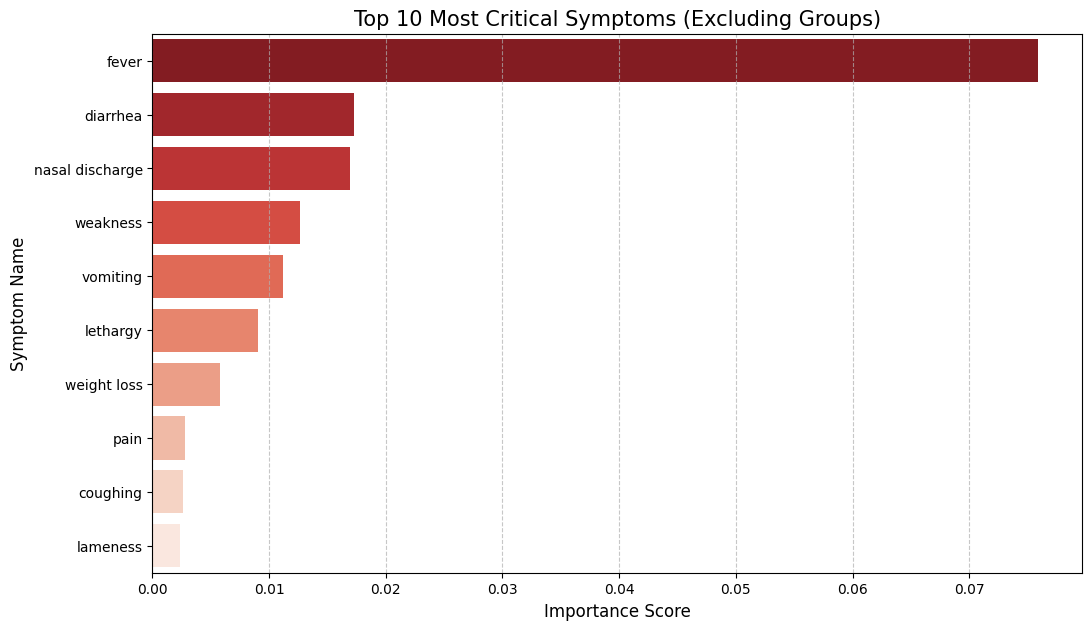

📌 10 อันดับอาการป่วยที่มีผลต่อความเสี่ยงมากที่สุด:
   1. fever (Score: 0.0759)
   2. diarrhea (Score: 0.0173)
   3. nasal discharge (Score: 0.0169)
   4. weakness (Score: 0.0127)
   5. vomiting (Score: 0.0112)
   6. lethargy (Score: 0.0091)
   7. weight loss (Score: 0.0058)
   8. pain (Score: 0.0028)
   9. coughing (Score: 0.0026)
   10. lameness (Score: 0.0024)


In [14]:
# --- ส่วนที่เพิ่ม: วิเคราะห์ 10 อันดับอาการป่วยที่สำคัญที่สุด (ไม่รวมกลุ่มสัตว์) ---

# 1. สร้าง DataFrame แสดงความสำคัญของคุณลักษณะทั้งหมด
all_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# 2. กรองเอาเฉพาะ "อาการป่วย" (คอลัมน์ที่ไม่ขึ้นต้นด้วย 'Group_')
symptom_importance = all_importances[~all_importances['Feature'].str.startswith('Group_')]

# 3. เรียงลำดับจากมากไปน้อย และเลือก 10 อันดับแรก
top_10_symptoms = symptom_importance.sort_values(by='Importance', ascending=False).head(10)

# 4. แสดงผลเป็นกราฟแท่ง
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_symptoms, palette='Reds_r')
plt.title('Top 10 Most Critical Symptoms (Excluding Groups)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Symptom Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. พิมพ์รายชื่อออกมาเป็นข้อความ (สำหรับนำไปใส่ในรายงาน)
print("📌 10 อันดับอาการป่วยที่มีผลต่อความเสี่ยงมากที่สุด:")
for i, (idx, row) in enumerate(top_10_symptoms.iterrows(), 1):
    print(f"   {i}. {row['Feature']} (Score: {row['Importance']:.4f})")